In [11]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from the uploaded CSV file
df = pd.read_csv('s.csv')

# Preprocess features: Convert text strings to numeric and fill missing values with 0.0
df['Reviews_Cleaned'] = pd.to_numeric(df['Reviews'], errors='coerce').fillna(0.0)
df['Comments_Cleaned'] = pd.to_numeric(df['Comments'], errors='coerce').fillna(0.0)

# Clean and normalize business categories
df['Category'] = df['Category'].fillna('Unknown').str.strip().str.title()

print(f"Dataset successfully loaded. Total rows: {len(df)}")
df[['S.No.', 'Company', 'Category', 'Reviews_Cleaned', 'Comments_Cleaned']].head()

Dataset successfully loaded. Total rows: 288


,S.No.,Company,Category,Reviews_Cleaned,Comments_Cleaned
0,1,A&J Dance Studio,Training Center,4.9,8.0
1,2,DANCE STUDIO & NUTRITION CENTER,Dance School,5.0,4.0
2,3,DanceHub,Dance School,5.0,2.0
3,4,Magic Dance Studio,Dance School,5.0,1.0
4,5,Aadarsh Urogynec Clinic - Dr Mahesh sonwal Alwar,Medical Clinic,4.7,55.0


In [4]:
# Define target proxy indicator using a combination of reviews and active comment engagement
# High baseline reviews combined with strong comment activity indicates premium conversion intent
median_comments = df['Comments_Cleaned'].median()
df['Target_Label'] = ((df['Reviews_Cleaned'] >= 4.5) & (df['Comments_Cleaned'] >= median_comments)).astype(int)

# Isolate features based on both reviews and comments
X = df[['Reviews_Cleaned', 'Comments_Cleaned']]
y = df['Target_Label']

# Initialize and fit a Logistic Regression classifier
model = LogisticRegression(random_state=42)
model.fit(X, y)

# Extract continuous predicted probabilities for lead conversion
df['Predicted_Probability'] = model.predict_proba(X)[:, 1]

print("Predictive model successfully trained on review and comment signals.")

Predictive model successfully trained on review and comment signals.


In [12]:
# Sort the entire dataset globally by Predicted_Probability (Descending)
# Breaking probability ties predictably using raw review and comment metrics
df_sorted = df.sort_values(
    by=['Predicted_Probability', 'Reviews_Cleaned', 'Comments_Cleaned'], 
    ascending=[False, False, False]
).reset_index(drop=True)

# Slice into structural priority buckets matching the 297 total records
high_priority = df_sorted.iloc[0:83].copy()
medium_priority = df_sorted.iloc[83:193].copy()  # 83 + 110 = 193
low_priority = df_sorted.iloc[193:297].copy()     # 193 + 104 = 297 total records

print(f"Global Sorting & Prioritization Complete:")
print(f"-> Top / High Priority Category Count: {len(high_priority)}")
print(f"-> Medium Priority Category Count: {len(medium_priority)}")
print(f"-> Low / Small Priority Category Count: {len(low_priority)}")

KeyError: 'Predicted_Probability'

In [8]:
# Strict list of columns permitted for the final output
columns_to_export = [
    "S.No",
    "Country",
    "City",
    "Company",
    "CONTACT",
    "Google Map",
    "Category",
    "Predicted_Probability"
]

# Apply structural column selection filtering
high_priority_final = high_priority[columns_to_export]
medium_priority_final = medium_priority[columns_to_export]
low_priority_final = low_priority[columns_to_export]

# Export to separate sheets inside a single Excel spreadsheet document
output_filename = 'Reviews_and_Comments_based_leads 1.xlsx'
with pd.ExcelWriter(output_filename) as writer:
    high_priority_final.to_excel(writer, sheet_name=f'High Priority ({len(high_priority)})', index=False)
    medium_priority_final.to_excel(writer, sheet_name=f'Medium Priority ({len(medium_priority)})', index=False)
    low_priority_final.to_excel(writer, sheet_name=f'Low Priority ({len(low_priority)})', index=False)

print(f"Excel File successfully created: '{output_filename}'")

Excel File successfully created: 'Reviews_and_Comments_based_leads 1.xlsx'


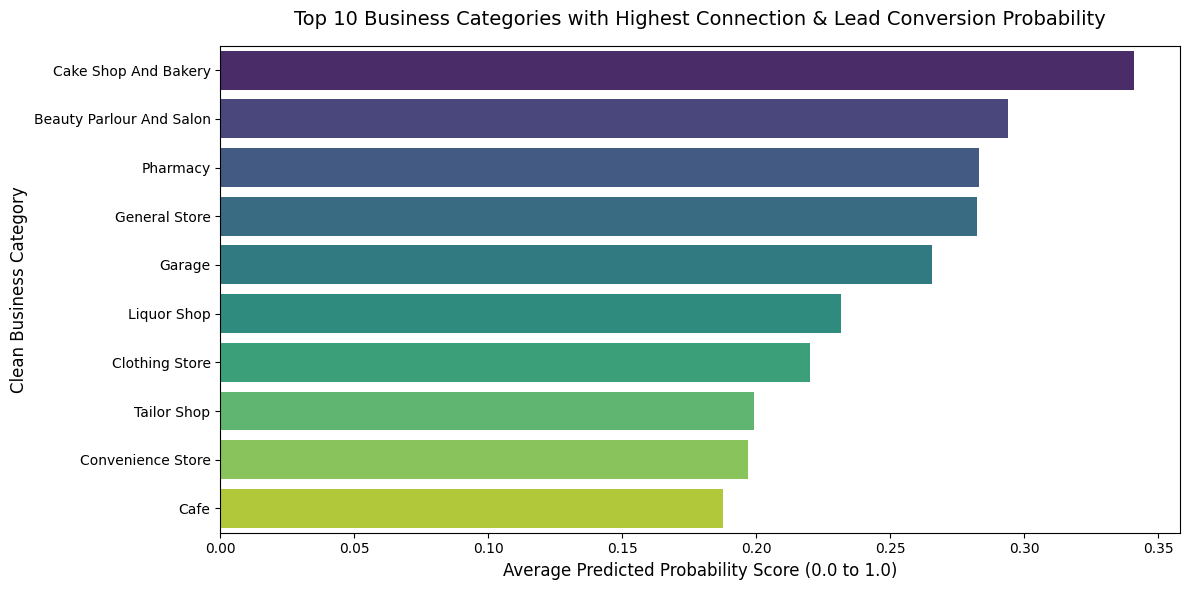

Visualization generated and saved successfully as 'top_converting_categories_updated.png'.


In [9]:
# Recombine high and medium priority data streams for category analysis
visualization_df = pd.concat([high_priority_final, medium_priority_final])

# Aggregate the mean predicted probability per business category using only the specified columns
category_performance = visualization_df.groupby('Category')['Predicted_Probability'].mean().reset_index()
category_performance_sorted = category_performance.sort_values(by='Predicted_Probability', ascending=False).head(10)

# Generate chart visualization
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=category_performance_sorted, 
    x='Predicted_Probability', 
    y='Category', 
    ax=ax, 
    palette='viridis',
    hue='Category'
)

ax.set_title('Top 10 Business Categories with Highest Connection & Lead Conversion Probability', fontsize=14, pad=15)
ax.set_xlabel('Average Predicted Probability Score (0.0 to 1.0)', fontsize=12)
ax.set_ylabel('Clean Business Category', fontsize=12)

plt.tight_layout()
plt.savefig('top_converting_categories_updated.png', dpi=300)
plt.show()
print("Visualization generated and saved successfully as 'top_converting_categories_updated.png'.")